In [1]:
import sys
sys.path.append("..")


from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR= "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)


In [3]:
import src.torch.pre_processing.graph_batching as graph_batching
from importlib import reload
reload(graph_batching)

graph_builder = graph_batching.CombinedGraphBuilder(connect_layers=True, mppc_timing_cutoff=0.1)
event_processor = graph_batching.EventProcessor(graph_builder=graph_builder)

Event has 14 MPPC hits and 14 Pixel hits


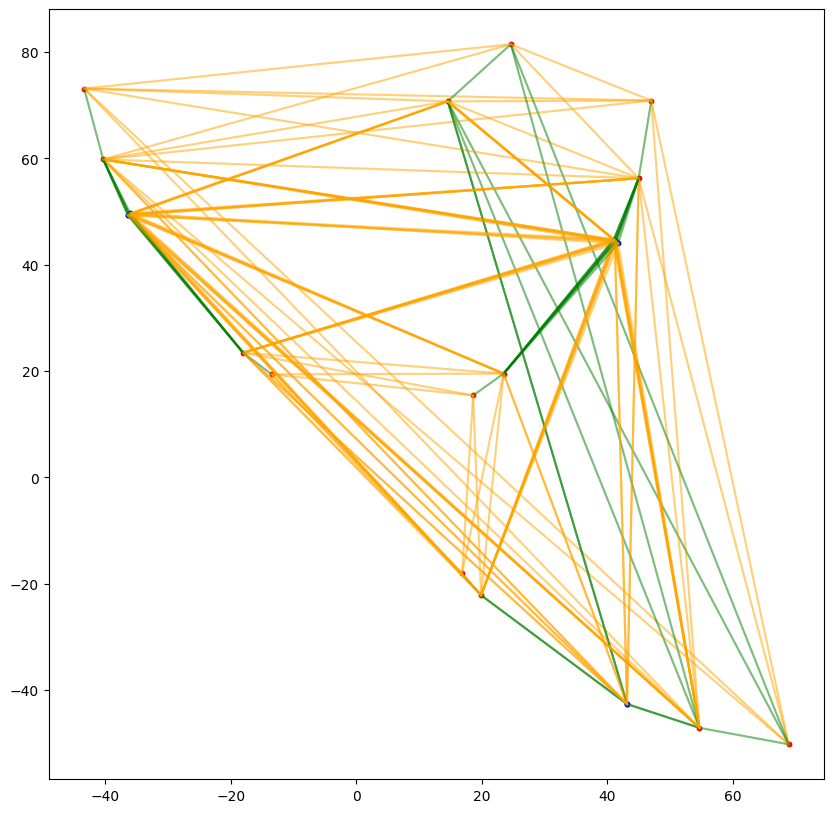

In [32]:
event_id = 18
graphs_bg = event_processor.process_single_event(X_pixel=sig_only_pixel_spacetime[event_id], X_mppc=sig_only_mppc_spacetime[event_id], labels=None)

fig, ax = plt.subplots(1, figsize=(10, 10))
graph = graphs_bg[0]
mppc_nodes = graph.x[graph.x[:, 3] == 0]
pixel_nodes = graph.x[graph.x[:, 3] == 1]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c='blue', s=10, label='MPPC hits')
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c='red', s=10, label='Pixel hits')
for edge_index in range(graph.edge_index.shape[1]):
    edge = graph.edge_index[:, edge_index]
    if graph.edge_labels[edge_index] == 1:
        color = "green"
    else:
        color = "orange"
    ax.plot(
        [graph.x[edge[0], 0], graph.x[edge[1], 0]],
        [graph.x[edge[0], 1], graph.x[edge[1], 1]],
        c=color,
        alpha=0.3,
    )
print(f"Event has {(graph.x[:, 3] == 0).sum()} MPPC hits and {(graph.x[:, 3] == 1).sum()} Pixel hits")

In [18]:
graphs_bg[0].x

tensor([[-2.8522e+01,  7.9845e+00, -5.9470e+01,  1.0000e+00,  3.2000e+01],
        [-7.2014e+01, -4.8038e+00, -2.1380e+01,  1.0000e+00,  3.2000e+01],
        [-8.4096e+01, -1.3021e+01, -9.3500e+00,  1.0000e+00,  3.2000e+01],
        [-6.2736e+01, -1.1526e-01,  1.5012e+02,  0.0000e+00,  3.6650e+01],
        [-6.2735e+01, -1.1852e-01, -1.3762e+02,  0.0000e+00,  3.7500e+01]])

In [20]:
(sig_only_pixel_spacetime[event_id:event_id+1, : ,:3 ])

array([[[-28.52161622,   7.98445096, -59.47      ],
        [-72.01406609,  -4.80381917, -21.38      ],
        [-84.0959298 , -13.0206277 ,  -9.35      ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        ],
        [ -1